In [4]:
from a_NN_Samplers_and_VI_algo import *

#torch.manual_seed(128)
def loss_fct(W1,W2):
    return (W1*W2-1)**2

def sample_point_cloud(start_p, N_endpoints, N_steps, step_size, type= 'no drift', random_seed = None):
    
    startp = torch.tensor([start_p[0],start_p[1]], dtype = torch.float64)

    
    loss_fn = Losses_BANAN()
    # metric
    metric = RiemannianMetric(loss_fn)

    # sampler
    sampler = Brownian_sampler(metric, N_steps, step_size, n_samples=1)
    #ratio net
    sampler_eu = Euclidean_sampler(N_steps, step_size, n_samples=1)

    points = np.zeros((N_endpoints,2))
    if random_seed:
        seeds = np.floor(np.int64(100*np.random.rand(N_endpoints)))
        for i in range(N_endpoints):
            if type == 'no drift':
                points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=False, random_state = seeds[i]).detach().numpy()
            if type == 'drift':
                points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=True, random_state = seeds[i]).detach().numpy()
            if type == 'euclidean':
                points[i,:]= sampler_eu.sample_q_endpoints(startp, detach_from_mu = False, drift=False, random_state = seeds[i]).detach().numpy()
        return points 

    for i in range(N_endpoints):
        if type == 'no drift':
            points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=False).detach().numpy()
        if type == 'drift':
            points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=True).detach().numpy()
        if type == 'euclidean':
            points[i,:]= sampler_eu.sample_q_endpoints(startp, detach_from_mu = False, drift=False).detach().numpy()
    return points 

Load points into a file for plotting (in eg maple)

In [5]:
mu_p = [1.0,1.0]
N_points = 200
start_p = mu_p
points_q_T200_n001 = sample_point_cloud(start_p, N_points, 200, 0.001, type= 'drift', random_seed = None)
Points = np.zeros((len(points_q_T200_n001),3))
for i in range(len(points_q_T200_n001)):
    x, y = points_q_T200_n001[i][0], points_q_T200_n001[i][1]
    Points[i][0] = x
    Points[i][1] = y
    Points[i][2] = np.exp(-(x*y-1)**2)
with open("points.txt", "w") as f:
    for x, y, z in Points:
        f.write(f"{x} {y} {z}\n")


Show posteror point clouds

In [6]:
mu_p = [1.0,1.0]
N_points = 1000
start_p = mu_p
points_p = np.random.randn(N_points, 2)
points_q_T1000_n001 = sample_point_cloud(start_p, N_points, 1000, 0.01, type= 'drift', random_seed = None)
points_q_T500_n0005 = sample_point_cloud(start_p, N_points, 500, 0.005, type= 'drift', random_seed = None)
points_q_T100_n0001 = sample_point_cloud(start_p, N_points, 100, 0.001, type= 'drift', random_seed = None)
points_q_T100_n0001 = sample_point_cloud(start_p, N_points, 50, 0.001, type= 'drift', random_seed = None)
points_q_T50_n00005 = sample_point_cloud(start_p, N_points, 50, 0.0005, type= 'drift', random_seed = None)

In [7]:
mask1 = ((points_q_T1000_n001[:,0] >= -5) & (points_q_T1000_n001[:,0] <= 5) &
         (points_q_T1000_n001[:,1] >= -5) & (points_q_T1000_n001[:,1] <= 5))

mask2 = ((points_q_T500_n0005[:,0] >= -5) & (points_q_T500_n0005[:,0] <= 5) &
         (points_q_T500_n0005[:,1] >= -5) & (points_q_T500_n0005[:,1] <= 5))

mask3 = ((points_q_T100_n0001[:,0] >= -5) & (points_q_T100_n0001[:,0] <= 5) &
         (points_q_T100_n0001[:,1] >= -5) & (points_q_T100_n0001[:,1] <= 5))

mask4 = ((points_q_T50_n00005[:,0] >= -5) & (points_q_T50_n00005[:,0] <= 5) &
         (points_q_T50_n00005[:,1] >= -5) & (points_q_T50_n00005[:,1] <= 5))

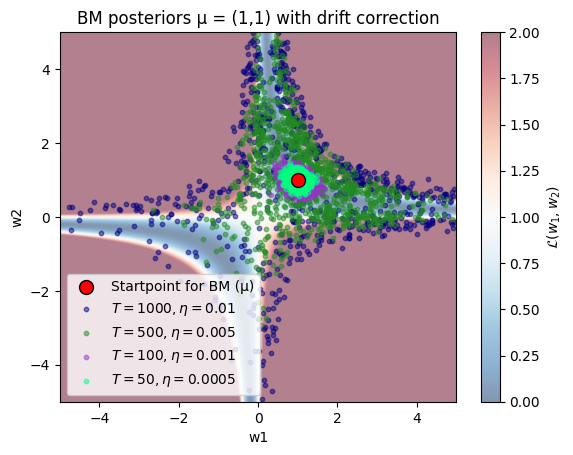

In [8]:
plot_loss(loss_fct, [-5,5], [-5,5], alone='no',
          color='RdBu_r',
          title='BM posteriors μ = (1,1) with drift correction')

plt.scatter(start_p[0], start_p[1],
            c='red', s=100, edgecolors='black',
            label='Startpoint for BM (μ)', zorder=15)

plt.scatter(points_q_T1000_n001[mask1,0], points_q_T1000_n001[mask1,1],
            alpha=0.5, s=10, label='$T=1000, \\eta=0.01$', c='navy')

plt.scatter(points_q_T500_n0005[mask2,0], points_q_T500_n0005[mask2,1],
            alpha=0.5, s=10, label='$T=500, \\eta=0.005$', c='forestgreen')

plt.scatter(points_q_T100_n0001[mask3,0], points_q_T100_n0001[mask3,1],
            alpha=0.5, s=10, label='$T=100, \\eta=0.001$', c='darkorchid')

plt.scatter(points_q_T50_n00005[mask4,0], points_q_T50_n00005[mask4,1],
            alpha=0.5, s=10, label='$T=50, \\eta=0.0005$', c='springgreen')

plt.legend(loc='lower left')
plt.show()

In [ ]:
mu_p = [1.0,1.0]
N_points = 1000
start_p = mu_p
points_p = np.random.randn(N_points, 2)
points_q_T1000_n001 = sample_point_cloud(start_p, N_points, 1000, 0.01, type= 'no drift', random_seed = None)
points_q_T500_n0005 = sample_point_cloud(start_p, N_points, 500, 0.005, type= 'no drift', random_seed = None)
points_q_T100_n0001 = sample_point_cloud(start_p, N_points, 100, 0.001, type= 'no drift', random_seed = None)
points_q_T50_n00005 = sample_point_cloud(start_p, N_points, 50, 0.0005, type= 'no drift', random_seed = None)

In [ ]:
mask1 = ((points_q_T1000_n001[:,0] >= -5) & (points_q_T1000_n001[:,0] <= 5) &
         (points_q_T1000_n001[:,1] >= -5) & (points_q_T1000_n001[:,1] <= 5))

mask2 = ((points_q_T500_n0005[:,0] >= -5) & (points_q_T500_n0005[:,0] <= 5) &
         (points_q_T500_n0005[:,1] >= -5) & (points_q_T500_n0005[:,1] <= 5))

mask3 = ((points_q_T100_n0001[:,0] >= -5) & (points_q_T100_n0001[:,0] <= 5) &
         (points_q_T100_n0001[:,1] >= -5) & (points_q_T100_n0001[:,1] <= 5))

mask4 = ((points_q_T50_n00005[:,0] >= -5) & (points_q_T50_n00005[:,0] <= 5) &
         (points_q_T50_n00005[:,1] >= -5) & (points_q_T50_n00005[:,1] <= 5))

plot_loss(loss_fct, [-5,5], [-5,5], alone='no',
          color='RdBu_r',
          title='BM posteriors μ = (1,1) without drift correction term')

plt.scatter(start_p[0], start_p[1],
            c='red', s=100, edgecolors='black',
            label='Startpoint for BM (μ)', zorder=15)

plt.scatter(points_q_T1000_n001[mask1,0], points_q_T1000_n001[mask1,1],
            alpha=0.5, s=10, label='$T=1000, \\eta=0.01$', c='navy')

plt.scatter(points_q_T500_n0005[mask2,0], points_q_T500_n0005[mask2,1],
            alpha=0.5, s=10, label='$T=500, \\eta=0.005$', c='forestgreen')

plt.scatter(points_q_T100_n0001[mask3,0], points_q_T100_n0001[mask3,1],
            alpha=0.5, s=10, label='$T=100, \\eta=0.001$', c='darkorchid')

plt.scatter(points_q_T50_n00005[mask4,0], points_q_T50_n00005[mask4,1],
            alpha=0.5, s=10, label='$T=50, \\eta=0.0005$', c='springgreen')

plt.legend(loc='lower left')
plt.show()